# Final Model Results on Test Set

Confusion Matrix:

[[14760   865] TP FP

 [   11   364]] FN TN

 Cost of False Predictions = $14,150


# Summary 

After doing some EDA, these are the key insights
- Class imbalance (59000 -ve and 1000+ve)
- NAs present in dataset
- 170 attributes / predictors 
  
This meant that I would have to
- Use stratify option when splitting data to ensure class distribution
- Fills NAs with 0, decided after doing some EDA
- Scale data
- Dimension reduction for predictors

I scale the data using `StandardScaler()` and applied `PCA` from `Scikit` learn. I choose `N_COMPONENTS=30` initially, and looked at decided to narrow it down to the first 20 components due to the explained variance. I decided to try classical machine learning methods for this and compared `RandomForestClassifier, LogisticRegression, SVC`. `LogisticRegression` performed the best. 

I decided to split the train data into train-val, and use the test data provided only for the final evaluation to prevent leakage. 

### Model Evaluation
Noticing that FN cost 50x more than FP, I decided to prioritise increasing Recall as much as possible, thus reducing the number of FNs. After training the LogisticRegression model, I used `predict_proba` to get the probabilities. I iterate from 0 to 1 for the threshold numbers, keeping track of the costs after deriving the confusion metrics and picking the threshold (0.222) with the lowest cost. 

> I noticed that I performed this evaluation wrongly on the results after the test set, and should have done it on the training set instead. However, I ran out of time and power to fix that. There was a tornado alert in Pittsburgh and we are out of power :(

In the end, the model predicted 11 False Negatives and 865 False Positives, for a total cost of $14,150. The metrics are below. While the precision score suffered, I believe the trade off is worth it for the high Recall score due to the nature of the problem.

# Metrics at Threshold = 0.2222:
Accuracy:  0.9453

Recall:    0.9707

Precision: 0.2962

F1 Score:  0.4539

ROC AUC:   0.9904


# Future Improvements

Some future improvements I will want to do given enough time are
- Explore more feature engineering and do more EDA. Having annoymized data names makes it hard to create new features that may hold more meaning and be better predictors
- Perform grid / randomized search on various models. I tried performing RandomizedSearchCV but it was prohibitively long on my laptop. 
- Find the best threshold on the training set instead of the test set (this was a mistsake on my part I had no time to fix)
- Try a neural network model



Thank you for the opportunity.

# EDA

In [1]:
import pandas as pd
import numpy as np

In [2]:
FILENAME = "data/aps_failure_training_set.csv"
df = pd.read_csv(FILENAME)
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0


In [3]:
df.info()
# All of tem seem to be int, there is some NA though
columns_to_exclude = ['class']  # Add other column names you want to exclude

columns_to_convert = [col for col in df.columns if col not in columns_to_exclude]

for col in columns_to_convert:
    df[col] = df[col].replace('na', 0) # replace 'na' with 0
    df[col] = df[col].fillna(0).astype(float)
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: int64(1), object(170)
memory usage: 78.3+ MB
class      object
aa_000    float64
ab_000    float64
ac_000    float64
ad_000    float64
           ...   
ee_007    float64
ee_008    float64
ee_009    float64
ef_000    float64
eg_000    float64
Length: 171, dtype: object


In [4]:
from sklearn.preprocessing import StandardScaler

numeric_cols = columns_to_convert # same
X = df[numeric_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y = df['class']
# change from y == pos to y= 1
y = (y == 'pos').astype(int)

In [5]:
from sklearn.decomposition import PCA

N_COMPONENTS = 30

pca = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=[f'pca_{i}' for i in range(N_COMPONENTS)])

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Shape of original data: {X.shape}")
print(f"Shape after PCA: {X_pca.shape}")
print("\nExplained variance ratio by each component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({cumulative_variance[i]:.4f} cumulative)")

Shape of original data: (60000, 170)
Shape after PCA: (60000, 30)

Explained variance ratio by each component:
PC1: 0.2852 (0.2852 cumulative)
PC2: 0.0473 (0.3325 cumulative)
PC3: 0.0410 (0.3735 cumulative)
PC4: 0.0367 (0.4102 cumulative)
PC5: 0.0289 (0.4391 cumulative)
PC6: 0.0235 (0.4625 cumulative)
PC7: 0.0194 (0.4819 cumulative)
PC8: 0.0176 (0.4996 cumulative)
PC9: 0.0176 (0.5172 cumulative)
PC10: 0.0157 (0.5329 cumulative)
PC11: 0.0143 (0.5473 cumulative)
PC12: 0.0138 (0.5611 cumulative)
PC13: 0.0122 (0.5733 cumulative)
PC14: 0.0116 (0.5849 cumulative)
PC15: 0.0113 (0.5962 cumulative)
PC16: 0.0108 (0.6071 cumulative)
PC17: 0.0102 (0.6172 cumulative)
PC18: 0.0101 (0.6273 cumulative)
PC19: 0.0097 (0.6370 cumulative)
PC20: 0.0097 (0.6467 cumulative)
PC21: 0.0093 (0.6560 cumulative)
PC22: 0.0091 (0.6651 cumulative)
PC23: 0.0090 (0.6742 cumulative)
PC24: 0.0087 (0.6829 cumulative)
PC25: 0.0079 (0.6908 cumulative)
PC26: 0.0077 (0.6985 cumulative)
PC27: 0.0076 (0.7061 cumulative)
PC28: 0

In [6]:
X_reduced = X_pca[:, :20]


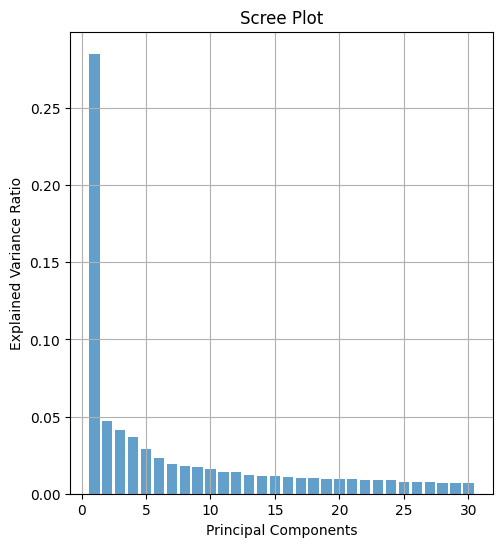

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, alpha=0.7)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)


# Modelling

In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold

In [9]:
# Splitting this into train-test (val) and using the test data 
# provided as the final test set to ensure no leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2,
    stratify=y, random_state=42
    )
print("Original class distribution:")
print(y.value_counts(normalize=True))

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))


Original class distribution:
class
0    0.983333
1    0.016667
Name: proportion, dtype: float64

Training set class distribution:
class
0    0.983333
1    0.016667
Name: proportion, dtype: float64

Test set class distribution:
class
0    0.983333
1    0.016667
Name: proportion, dtype: float64


In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from tqdm import tqdm
from sklearn.model_selection import GridSearchCV
import numpy as np

# param_grids = {
#     'RandomForest': {
#         'n_estimators': [100, 200, 300],
#         'max_depth': [None, 10, 20, 30],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#     },
#     'LogisticRegression': {
#         'C': [0.1, 1, 10, 100],
#         'solver': ['liblinear', 'saga'],
#         'penalty': ['l2'],
#     },
#     'SVM': {
#         'C': [0.1, 1, 10],
#         'kernel': ['linear', 'rbf'],
#         'gamma': ['scale', 'auto'],
#     }
# }
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in tqdm(models.items(), desc="Evaluating models", total=len(models)):
    f1_scores = []
    auc_scores = []

    for train_idx, test_idx in tqdm(cv.split(X_train, y_train), total=cv.get_n_splits(), desc=f"{name} CV", leave=False):
        X_fold_train, X_fold_test = X_train[train_idx], X_train[test_idx]
        y_fold_train, y_fold_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

        model.fit(X_fold_train, y_fold_train)
        y_fold_pred = model.predict(X_fold_test)
        f1 = f1_score(y_fold_test, y_fold_pred, average='weighted')
        f1_scores.append(f1)

        if hasattr(model, "predict_proba"):
            y_fold_prob = model.predict_proba(X_fold_test)[:, 1]
        else:
            y_fold_prob = model.decision_function(X_fold_test)
        auc = roc_auc_score(y_fold_test, y_fold_prob)
        auc_scores.append(auc)

    f1_scores = np.array(f1_scores)
    auc_scores = np.array(auc_scores)

    results[name] = {
        'F1-weighted': f1_scores.mean(),
        'AUC': auc_scores.mean()
    }

    print(f"\nModel: {name}")
    print(f"F1-weighted: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print("-----")

best_model_name = max(results, key=lambda x: results[x]['AUC'])
best_model = models[best_model_name]

print(f"\nTraining best model: {best_model_name}")
with tqdm(total=100, desc="Training model") as pbar:
    best_model.fit(X_train, y_train)
    pbar.update(100)

print("Making predictions...")
with tqdm(total=100, desc="Predicting") as pbar:
    y_pred = best_model.predict(X_test)
    pbar.update(50)
    y_prob = best_model.predict_proba(X_test)[:, 1]
    pbar.update(50)

print(f"\nBest Model: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision Score: {average_precision_score(y_test, y_prob):.4f}")


Evaluating models:  33%|███▎      | 1/3 [00:47<01:35, 47.60s/it]


Model: RandomForest
F1-weighted: 0.9885 ± 0.0009
AUC: 0.9766 ± 0.0054
-----


Evaluating models:  67%|██████▋   | 2/3 [00:47<00:19, 19.74s/it]


Model: LogisticRegression
F1-weighted: 0.9759 ± 0.0017
AUC: 0.9767 ± 0.0071
-----


Evaluating models: 100%|██████████| 3/3 [03:14<00:00, 64.70s/it]



Model: SVM
F1-weighted: 0.9800 ± 0.0012
AUC: 0.9641 ± 0.0052
-----

Training best model: LogisticRegression


Training model: 100%|██████████| 100/100 [00:00<00:00, 1776.44it/s]


Making predictions...


Predicting: 100%|██████████| 100/100 [00:00<00:00, 56910.50it/s]


Best Model: LogisticRegression

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     11800
           1       0.34      0.94      0.50       200

    accuracy                           0.97     12000
   macro avg       0.67      0.96      0.74     12000
weighted avg       0.99      0.97      0.98     12000


Confusion Matrix:
[[11431   369]
 [   11   189]]

ROC AUC Score: 0.9845
Average Precision Score: 0.6582


# Evaluation

In [15]:
TEST_FILENAME = "data/aps_failure_test_set.csv"
actl_test_df = pd.read_csv(TEST_FILENAME)
actl_test_df.head()
actl_test_df.shape

(16000, 171)

In [16]:
# # apply the same preprocessing steps
# scaler 
# pca
X_test = actl_test_df.drop(["class"], axis=1)

for col in columns_to_convert:
    X_test[col] = X_test[col].replace('na', 0) # replace 'na' with 0
    X_test[col] = X_test[col].fillna(0).astype(float)

y_test = actl_test_df["class"]
# change from y == pos to y= 1
y_test = (y_test == 'pos').astype(int)

# transform
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)
X_test_pca = X_test_pca[:, :20]

# predict
y_proba = best_model.predict_proba(X_test_pca)

/Users/xun/.virtualenvs/idl_hw1/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [17]:
print(X_test_pca.shape)
print(y_test.shape)
print(y_proba.shape)

(16000, 20)
(16000,)
(16000, 2)


In [18]:
COST_FP = 10
COST_FN = 500

best_threshold = 0.5
min_cost = float('inf')

thresholds = np.linspace(0, 1, 100)

for threshold in thresholds:
    y_pred = (y_proba[:, 1] > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost = (fp * COST_FP) + (fn * COST_FN)
    
    if cost < min_cost:
        min_cost = cost
        best_threshold = threshold

print(f"Best threshold: {best_threshold:.4f}")
print(f"Min cost: {min_cost:.4f}")

y_pred_final = (y_proba[:, 1] >= best_threshold).astype(int)

Best threshold: 0.2222
Min cost: 14150.0000


# Metrics on Test Set

At the threshold of 0.2222, the total cost of false predictions is **$14, 150**, and is broken down into
* 11 * $500 (FN)
* 865 * $10 (FP)

These are the metrics, and the confusion matrix is plotted below. 

Accuracy:  0.9453

Recall:    0.9707

Precision: 0.2962

F1 Score:  0.4539

ROC AUC:   0.9904



Metrics Threshold (0.2222):
Accuracy:  0.9453
Recall:    0.9707
Precision: 0.2962
F1 Score:  0.4539
ROC AUC:   0.9904


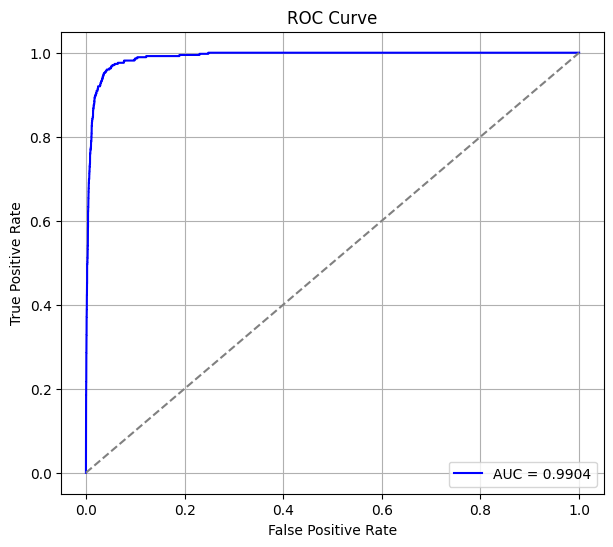

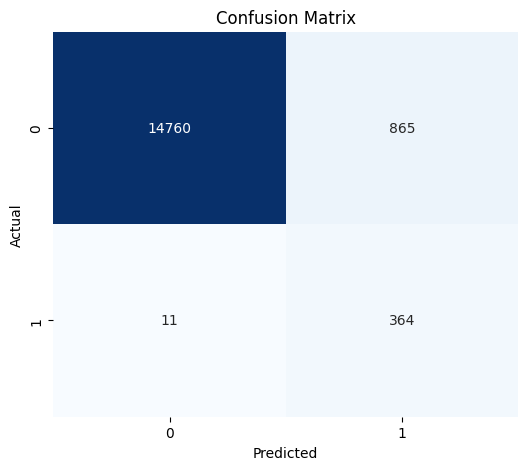

In [19]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve
import seaborn as sns

accuracy = accuracy_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_proba[:, 1])

print(f"\nMetrics Threshold ({best_threshold:.4f}):")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

def plot_confusion_matrix(y_true, y_pred, labels=[0, 1], title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_final, labels=[0, 1])


